# Tomato YOLOv8 Full Pipeline with Negative Images

**Goal:** train a YOLOv8 model that detects and classifies tomato diseases, while ignoring non-tomato objects such as apples, bananas, peppers, faces, hands and other vegetables.

This notebook starts directly from two ZIP files stored in Google Drive:

1. A tomato dataset already annotated in YOLOv8 format.
2. A negative images ZIP containing non-tomato images.

The negative images are automatically added to the YOLOv8 dataset with **empty label files**. Empty labels teach YOLOv8 that no tomato-related object should be detected in those images.

Pipeline:

1. Mount Google Drive.
2. Load the tomato dataset ZIP and negative images ZIP from Drive.
3. Extract the tomato dataset.
4. Fix `data.yaml` paths.
5. Extract negative images.
6. Convert `.HEIC` images to `.jpg`.
7. Remove duplicate negative images.
8. Add negative images to train/valid/test with empty labels.
9. Train a baseline YOLOv8n model.
10. Evaluate metrics and losses to check overfitting.
11. Train an improved YOLOv8n model with data augmentation.
12. Evaluate the improved model.
13. Test robustness on negative images with `conf=0.50`.
14. Save the final best model and results to Google Drive.

## 1. Install dependencies

Run this cell first. The notebook uses Ultralytics YOLOv8, OpenCV, Pandas, Matplotlib and Pillow.

In [ ]:
!pip install -q ultralytics opencv-python pillow pillow-heif pandas matplotlib seaborn scikit-learn pyyaml tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 136.5 MB/s eta 0:00:00


## 2. Import libraries

In [ ]:
from pathlib import Path
import os
import zipfile
import shutil
import random
import hashlib
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

try:
    import pillow_heif
    pillow_heif.register_heif_opener()
except Exception as e:
    print("pillow-heif not available or already registered:", e)

random.seed(42)
np.random.seed(42)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Mount Google Drive

Your Drive folder should contain the two ZIP files shown in your screenshot:

- `Tomato Fruit  Disease Detection.v1i.yolov8 (2).zip`
- `negative_images.zip`

The folder is expected to be:

```text
/content/drive/MyDrive/tomato_yolov8_project
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

print("Folders in MyDrive:")
for p in MYDRIVE.iterdir():
    if p.is_dir():
        print("-", p.name)

Mounted at /content/drive
Folders in MyDrive:
- Colab Notebooks
- Classroom
- UNI DTA
- Negative_images
- Vegetables and fruits


In [ ]:
from pathlib import Path

matches = list(Path("/content/drive").rglob("tomato_yolov8_project"))

print("Matches found:")
for m in matches:
    print(m)

Matches found:
/content/drive/MyDrive/tomato_yolov8_project
/content/drive/.Encrypted/MyDrive/tomato_yolov8_project


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

DRIVE_PROJECT_DIR = Path('/content/drive/MyDrive/tomato_yolov8_project')
print('Drive project folder:', DRIVE_PROJECT_DIR)
print('Exists:', DRIVE_PROJECT_DIR.exists())

if not DRIVE_PROJECT_DIR.exists():
    raise FileNotFoundError(f"Drive folder not found: {DRIVE_PROJECT_DIR}. Please check the folder name.")

print('Files found in Drive folder:')
for p in DRIVE_PROJECT_DIR.iterdir():
    print('-', p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive project folder: /content/drive/MyDrive/tomato_yolov8_project
Exists: True
Files found in Drive folder:
- Tomato Fruit  Disease Detection.v1i.yolov8 (2).zip
- negative_images.zip


## 4. Automatically find the tomato ZIP and negative ZIP

This avoids errors when the file has spaces or `(2)` in the name.

In [ ]:
# Find tomato dataset zip automatically
tomato_candidates = list(DRIVE_PROJECT_DIR.glob('*Tomato*Disease*.zip')) + list(DRIVE_PROJECT_DIR.glob('*tomato*disease*.zip'))
negative_candidates = list(DRIVE_PROJECT_DIR.glob('*negative*.zip')) + list(DRIVE_PROJECT_DIR.glob('*Negative*.zip'))

print('Tomato ZIP candidates:')
for p in tomato_candidates:
    print('-', p)

print('Negative ZIP candidates:')
for p in negative_candidates:
    print('-', p)

if len(tomato_candidates) == 0:
    raise FileNotFoundError('No tomato dataset ZIP found. Make sure the file name contains Tomato and Disease.')

if len(negative_candidates) == 0:
    raise FileNotFoundError('No negative images ZIP found. Make sure the file name contains negative.')

TOMATO_ZIP_DRIVE = tomato_candidates[0]
NEGATIVE_ZIP_DRIVE = negative_candidates[0]

print('Selected tomato ZIP:', TOMATO_ZIP_DRIVE.name)
print('Selected negative ZIP:', NEGATIVE_ZIP_DRIVE.name)

Tomato ZIP candidates:
- /content/drive/MyDrive/tomato_yolov8_project/Tomato Fruit  Disease Detection.v1i.yolov8 (2).zip
Negative ZIP candidates:
- /content/drive/MyDrive/tomato_yolov8_project/negative_images.zip
Selected tomato ZIP: Tomato Fruit  Disease Detection.v1i.yolov8 (2).zip
Selected negative ZIP: negative_images.zip


## 5. Copy ZIP files from Drive to Colab local storage

Copying the ZIP files to `/content` makes extraction and training more stable and faster than reading everything directly from Drive.

In [ ]:
WORK_DIR = Path('/content/tomato_yolov8_work')
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True, exist_ok=True)

TOMATO_ZIP_LOCAL = WORK_DIR / TOMATO_ZIP_DRIVE.name
NEGATIVE_ZIP_LOCAL = WORK_DIR / NEGATIVE_ZIP_DRIVE.name

shutil.copy(TOMATO_ZIP_DRIVE, TOMATO_ZIP_LOCAL)
shutil.copy(NEGATIVE_ZIP_DRIVE, NEGATIVE_ZIP_LOCAL)

print('Copied tomato ZIP:', TOMATO_ZIP_LOCAL)
print('Copied negative ZIP:', NEGATIVE_ZIP_LOCAL)

Copied tomato ZIP: /content/tomato_yolov8_work/Tomato Fruit  Disease Detection.v1i.yolov8 (2).zip
Copied negative ZIP: /content/tomato_yolov8_work/negative_images.zip


## 6. Extract the tomato YOLOv8 dataset

The code searches automatically for `data.yaml` after extraction.

In [ ]:
TOMATO_EXTRACT_DIR = WORK_DIR / 'tomato_dataset_extracted'
if TOMATO_EXTRACT_DIR.exists():
    shutil.rmtree(TOMATO_EXTRACT_DIR)
TOMATO_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(TOMATO_ZIP_LOCAL, 'r') as z:
    z.extractall(TOMATO_EXTRACT_DIR)

# Find data.yaml automatically
yaml_files = list(TOMATO_EXTRACT_DIR.rglob('data.yaml'))
if len(yaml_files) == 0:
    raise FileNotFoundError('data.yaml not found in the tomato dataset ZIP.')

DATA_YAML = yaml_files[0]
DATASET_PATH = DATA_YAML.parent

print('DATASET_PATH:', DATASET_PATH)
print('DATA_YAML:', DATA_YAML)
print('Dataset content:')
for p in DATASET_PATH.iterdir():
    print('-', p.name)

DATASET_PATH: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8
DATA_YAML: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/data.yaml
Dataset content:
- data.yaml
- README.dataset.txt
- valid
- train
- README.roboflow.txt
- test


## 7. Fix `data.yaml` paths for Colab

YOLOv8 needs correct absolute paths to `train/images`, `valid/images` and `test/images`.

In [ ]:
with open(DATA_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)

# Roboflow usually uses train, valid, test folders
train_images = DATASET_PATH / 'train' / 'images'
valid_images = DATASET_PATH / 'valid' / 'images'
test_images = DATASET_PATH / 'test' / 'images'

if not train_images.exists():
    raise FileNotFoundError(f'Train images folder not found: {train_images}')
if not valid_images.exists():
    raise FileNotFoundError(f'Valid images folder not found: {valid_images}')
if not test_images.exists():
    raise FileNotFoundError(f'Test images folder not found: {test_images}')

data_cfg['train'] = str(train_images)
data_cfg['val'] = str(valid_images)
data_cfg['test'] = str(test_images)

with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print('Updated data.yaml:')
print(yaml.safe_dump(data_cfg, sort_keys=False))

Updated data.yaml:
train: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease
  Detection.v1i.yolov8/train/images
val: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/images
test: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/test/images
nc: 4
names:
- Anthracnose
- Blossom end rot
- Healthy Tomato
- Spotted wilt Virus
roboflow:
  workspace: tomato-disease-detection-fcgsf
  project: tomato-fruit-disease-detection
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/tomato-disease-detection-fcgsf/tomato-fruit-disease-detection/dataset/1



## 8. Dataset verification before adding negative images

This checks the number of images, labels, boxes, empty labels and invalid lines.

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

def verify_yolo_split(dataset_path, split):
    img_dir = dataset_path / split / 'images'
    label_dir = dataset_path / split / 'labels'
    images = [p for p in img_dir.rglob('*') if p.suffix.lower() in IMG_EXTS]
    labels = list(label_dir.rglob('*.txt')) if label_dir.exists() else []
    boxes = 0
    empty_labels = 0
    invalid_lines = 0
    missing_labels = 0

    for img in images:
        label = label_dir / f'{img.stem}.txt'
        if not label.exists():
            missing_labels += 1
            continue
        text = label.read_text().strip()
        if text == '':
            empty_labels += 1
            continue
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                boxes += 1
            else:
                invalid_lines += 1
    return {
        'split': split,
        'images': len(images),
        'labels': len(labels),
        'boxes': boxes,
        'missing_labels': missing_labels,
        'empty_labels': empty_labels,
        'invalid_lines': invalid_lines,
    }

before_summary = pd.DataFrame([verify_yolo_split(DATASET_PATH, s) for s in ['train', 'valid', 'test']])
before_summary

,split,images,labels,boxes,missing_labels,empty_labels,invalid_lines
0,train,1816,1816,2378,0,34,442
1,valid,113,113,114,0,0,58
2,test,114,114,165,0,2,22


## 9. Visualize tomato annotations before adding negatives

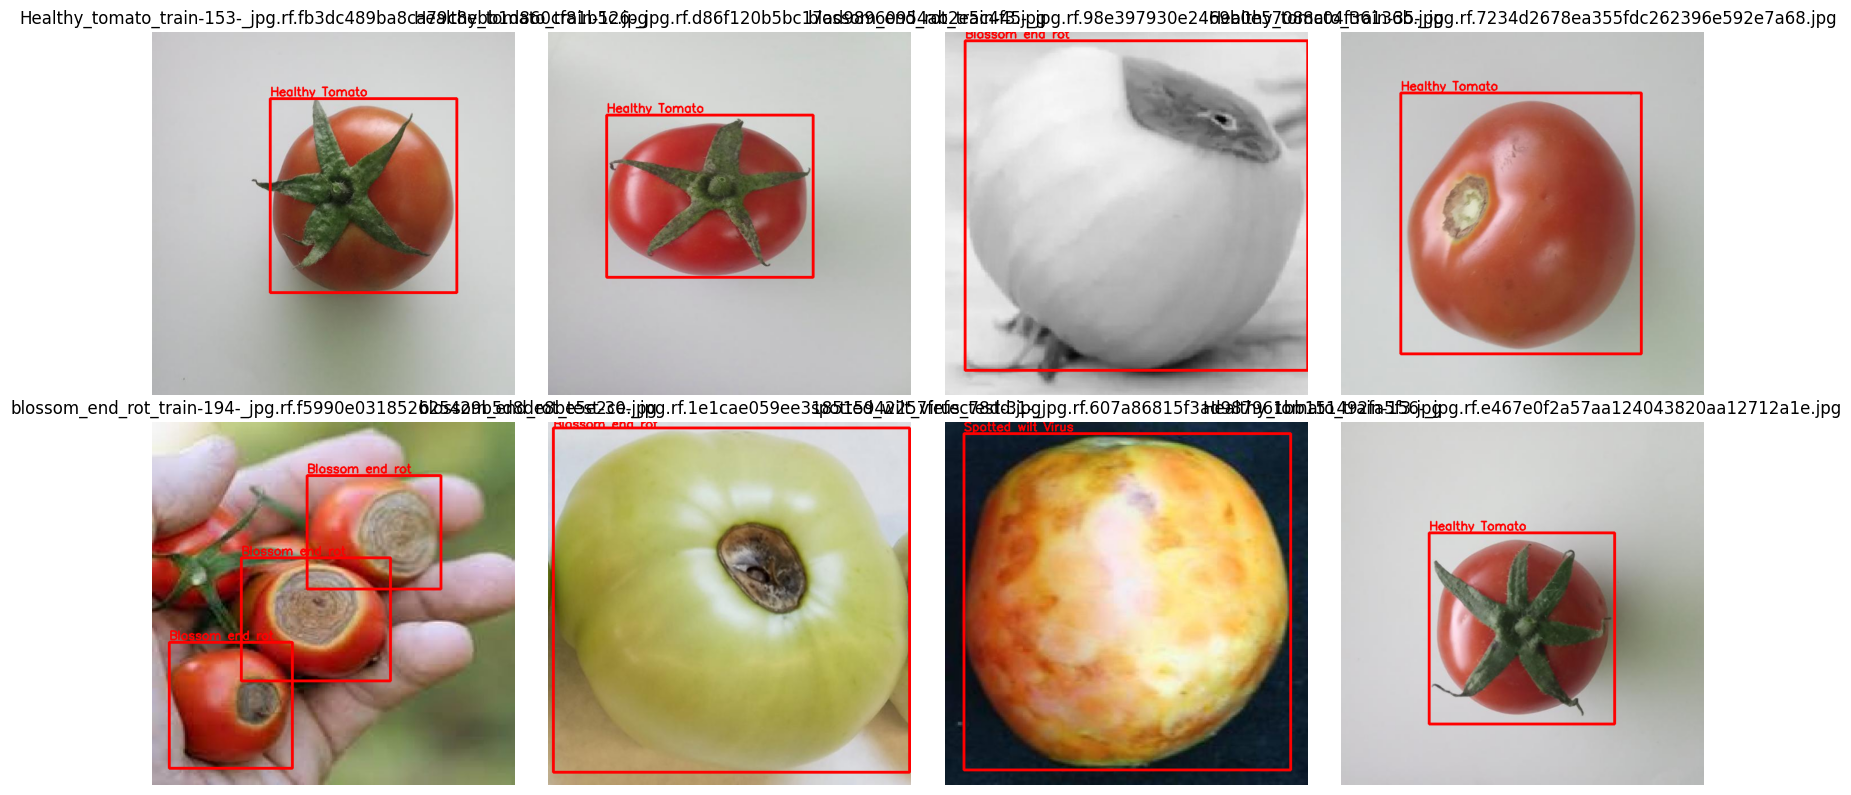

In [ ]:
import cv2

names = data_cfg.get('names', [])
if isinstance(names, dict):
    names = [names[k] for k in sorted(names.keys())]

def show_yolo_boxes(dataset_path, split='train', n=8):
    img_dir = dataset_path / split / 'images'
    label_dir = dataset_path / split / 'labels'
    images = [p for p in img_dir.rglob('*') if p.suffix.lower() in IMG_EXTS]
    random.shuffle(images)
    selected = images[:n]
    cols = 4
    rows = int(np.ceil(len(selected) / cols))
    plt.figure(figsize=(16, 4 * rows))
    for i, img_path in enumerate(selected):
        img = Image.open(img_path).convert('RGB')
        arr = np.array(img)
        h, w = arr.shape[:2]
        label_path = label_dir / f'{img_path.stem}.txt'
        if label_path.exists() and label_path.read_text().strip():
            for line in label_path.read_text().splitlines():
                parts = line.split()
                if len(parts) == 5:
                    cls, xc, yc, bw, bh = map(float, parts)
                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)
                    cv2.rectangle(arr, (x1, y1), (x2, y2), (255, 0, 0), 3)
                    label = names[int(cls)] if int(cls) < len(names) else str(int(cls))
                    cv2.putText(arr, label, (x1, max(y1-5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)
        plt.subplot(rows, cols, i+1)
        plt.imshow(arr)
        plt.title(img_path.name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_yolo_boxes(DATASET_PATH, 'train', n=8)

## 10. Extract negative images ZIP

These images are non-tomato images such as apples, bananas, peppers, faces, hands, vegetables and backgrounds.

In [ ]:
NEG_DIR = WORK_DIR / 'negative_images_extracted'
if NEG_DIR.exists():
    shutil.rmtree(NEG_DIR)
NEG_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(NEGATIVE_ZIP_LOCAL, 'r') as z:
    z.extractall(NEG_DIR)

print('Negative ZIP extracted to:', NEG_DIR)
print('Top-level files/folders:')
for p in list(NEG_DIR.iterdir())[:20]:
    print('-', p.name)

Negative ZIP extracted to: /content/tomato_yolov8_work/negative_images_extracted
Top-level files/folders:
- negative_images


## 11. Convert HEIC images to JPG

iPhone photos can be `.HEIC`. YOLOv8 works better with `.jpg`, `.jpeg` and `.png`, so this cell converts HEIC files to JPG.

In [ ]:
HEIC_EXTS = {'.heic', '.heif'}
converted = 0
failed = []

for heic_path in list(NEG_DIR.rglob('*')):
    if heic_path.suffix.lower() in HEIC_EXTS:
        jpg_path = heic_path.with_suffix('.jpg')
        try:
            img = Image.open(heic_path).convert('RGB')
            img.save(jpg_path, 'JPEG', quality=95)
            heic_path.unlink()
            converted += 1
        except Exception as e:
            failed.append((str(heic_path), str(e)))

print('HEIC converted:', converted)
print('HEIC failed:', len(failed))
if failed[:5]:
    print(failed[:5])

HEIC converted: 144
HEIC failed: 0


## 12. Collect and clean negative images

This cell:

- finds all negative images;
- removes duplicates using file hash;
- keeps a maximum of 300 images.

In [ ]:
NEG_IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

all_negative_images = [p for p in NEG_DIR.rglob('*') if p.suffix.lower() in NEG_IMG_EXTS]
print('Negative images found before duplicate removal:', len(all_negative_images))

def file_md5(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

unique_images = []
seen_hashes = set()
for img_path in all_negative_images:
    try:
        h = file_md5(img_path)
        if h not in seen_hashes:
            seen_hashes.add(h)
            unique_images.append(img_path)
    except Exception as e:
        print('Skipping unreadable file:', img_path, e)

random.shuffle(unique_images)
negative_images = unique_images[:300]

print('Unique negative images:', len(unique_images))
print('Negative images selected:', len(negative_images))

if len(negative_images) < 50:
    raise ValueError('Too few negative images. Please add more images to negative_images.zip.')

Negative images found before duplicate removal: 238
Unique negative images: 232
Negative images selected: 232


## 13. Visualize selected negative images

There should be no tomatoes in these images. They can contain apple, banana, pepper, carrot, onion, face, hand, table, kitchen, etc.

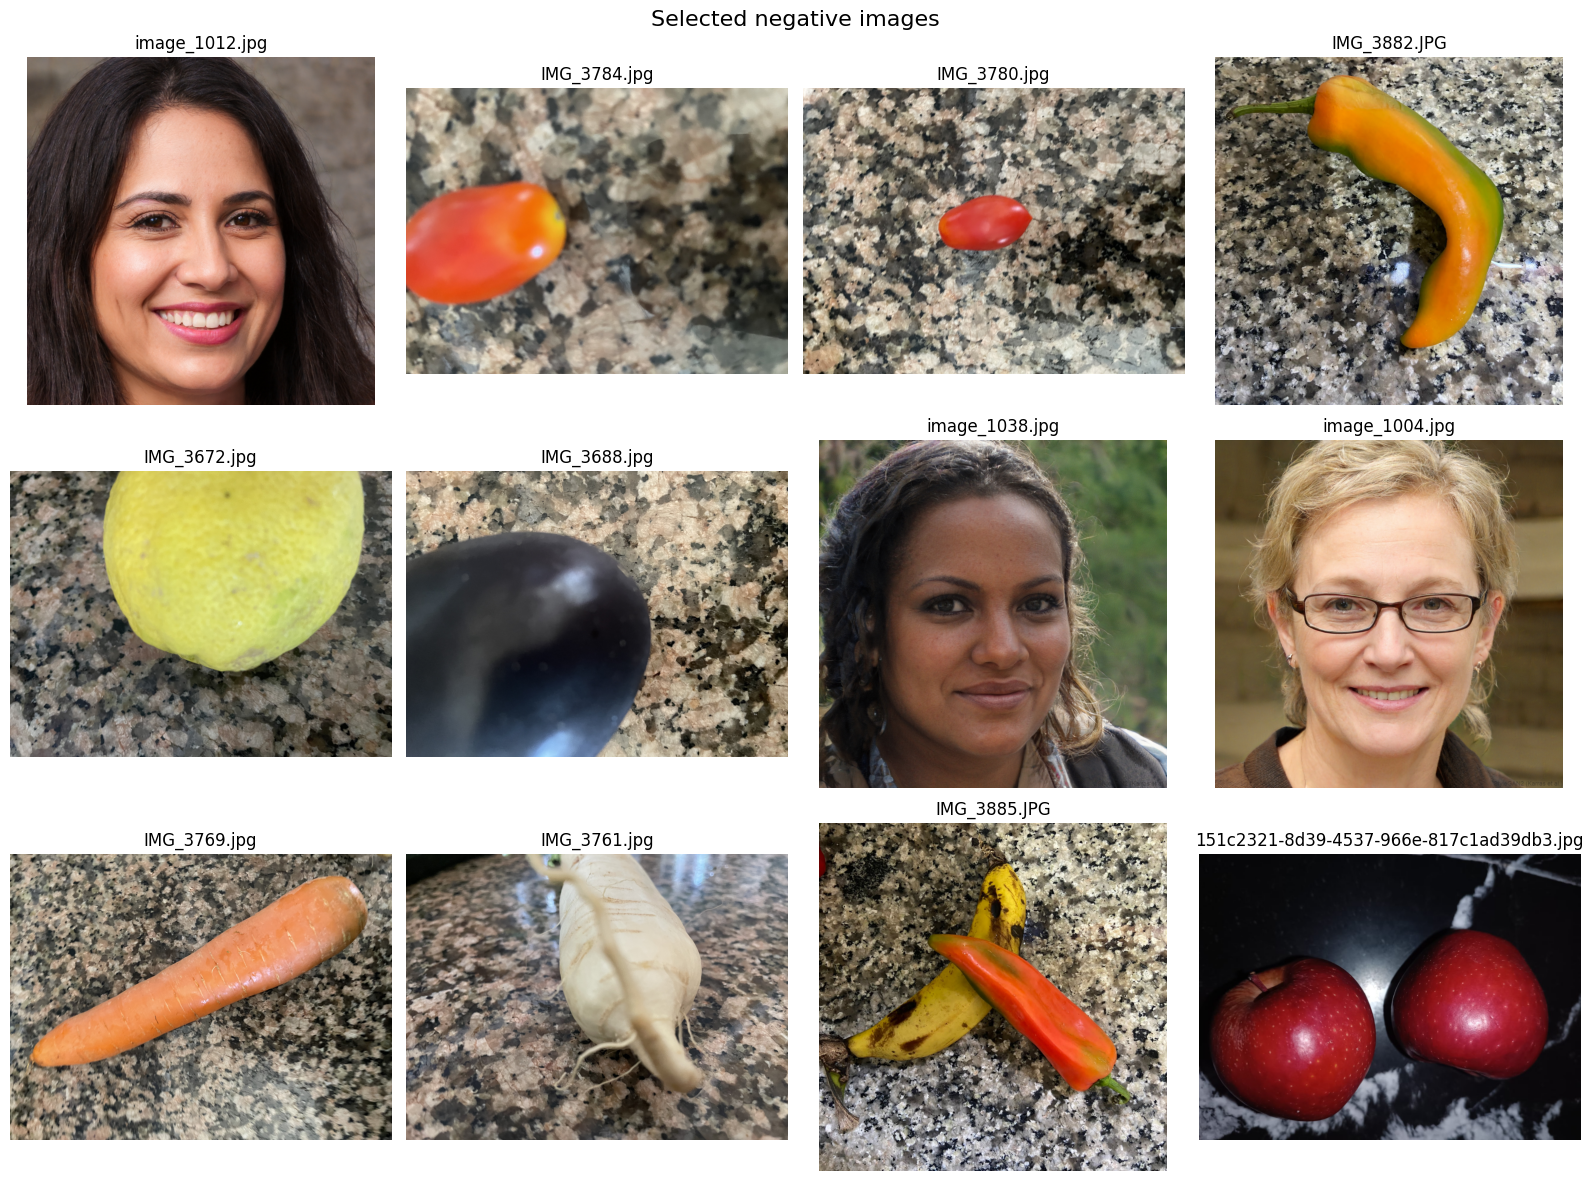

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
def show_images_grid(images, n=12, title='Negative images'):
    selected = images[:n]
    cols = 4
    rows = int(np.ceil(len(selected) / cols))
    plt.figure(figsize=(16, 4 * rows))
    for i, img_path in enumerate(selected):
        img = Image.open(img_path).convert('RGB')
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_images_grid(negative_images, n=min(12, len(negative_images)), title='Selected negative images')

## 14. Add negative images to YOLOv8 dataset with empty labels

Important:

- We do **not** add a new class such as `not_tomato`.
- Every negative image receives an empty `.txt` label file.
- Empty label means: no tomato object should be detected.

Split:

- 80% train
- 10% validation
- 10% test

If 300 images are available, this gives 240 train, 30 validation, 30 test.

In [ ]:
# Remove old negative_* files if the cell is re-run, to avoid duplicates
for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        folder = DATASET_PATH / split / sub
        if folder.exists():
            for f in folder.glob('negative_*'):
                f.unlink()

n_total = len(negative_images)
n_train = int(0.80 * n_total)
n_valid = int(0.10 * n_total)
n_test = n_total - n_train - n_valid

train_neg = negative_images[:n_train]
valid_neg = negative_images[n_train:n_train+n_valid]
test_neg = negative_images[n_train+n_valid:]

splits = {'train': train_neg, 'valid': valid_neg, 'test': test_neg}

for split, imgs in splits.items():
    img_out_dir = DATASET_PATH / split / 'images'
    label_out_dir = DATASET_PATH / split / 'labels'
    img_out_dir.mkdir(parents=True, exist_ok=True)
    label_out_dir.mkdir(parents=True, exist_ok=True)

    for i, img_path in enumerate(imgs):
        new_stem = f'negative_{split}_{i:04d}'
        new_img_path = img_out_dir / f'{new_stem}{img_path.suffix.lower()}'
        new_label_path = label_out_dir / f'{new_stem}.txt'
        shutil.copy(img_path, new_img_path)
        new_label_path.write_text('')  # empty label = no object

print('Negative images added successfully.')
print('Train negatives:', len(train_neg))
print('Valid negatives:', len(valid_neg))
print('Test negatives:', len(test_neg))

Negative images added successfully.
Train negatives: 185
Valid negatives: 23
Test negatives: 24


## 15. Verify dataset after adding negative images

In [ ]:
after_summary = pd.DataFrame([verify_yolo_split(DATASET_PATH, s) for s in ['train', 'valid', 'test']])
after_summary

,split,images,labels,boxes,missing_labels,empty_labels,invalid_lines
0,train,2001,2001,2378,0,219,442
1,valid,136,136,114,0,23,58
2,test,138,138,165,0,26,22


In [ ]:
# Verify that negative labels are empty
negative_check = []
for split in ['train', 'valid', 'test']:
    img_dir = DATASET_PATH / split / 'images'
    label_dir = DATASET_PATH / split / 'labels'
    neg_imgs = list(img_dir.glob('negative_*'))
    neg_labels = list(label_dir.glob('negative_*.txt'))
    empty_labels = [p for p in neg_labels if p.read_text().strip() == '']
    negative_check.append({
        'split': split,
        'negative_images': len(neg_imgs),
        'negative_labels': len(neg_labels),
        'empty_negative_labels': len(empty_labels)
    })

pd.DataFrame(negative_check)

,split,negative_images,negative_labels,empty_negative_labels
0,train,185,185,185
1,valid,23,23,23
2,test,24,24,24


## 16. Save dataset summaries to Drive

In [ ]:
OUTPUT_DIR = DRIVE_PROJECT_DIR / 'outputs_negative_pipeline'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

before_summary.to_csv(OUTPUT_DIR / 'dataset_summary_before_negatives.csv', index=False)
after_summary.to_csv(OUTPUT_DIR / 'dataset_summary_after_negatives.csv', index=False)

print('Saved dataset summaries to:', OUTPUT_DIR)

Saved dataset summaries to: /content/drive/MyDrive/tomato_yolov8_project/outputs_negative_pipeline


# Part A — Baseline training on tomato + negative dataset

The baseline model is trained on the combined dataset:

- annotated tomato images;
- negative images with empty labels.

This baseline allows us to evaluate the model before applying stronger augmentation.

## 17. Train baseline YOLOv8n model

For baseline, the augmentation is kept minimal to create a reference model.

In [ ]:
BASELINE_PROJECT = '/content/runs/detect'
BASELINE_NAME = 'tomato_yolov8n_baseline_with_negatives'

baseline_model = YOLO('yolov8n.pt')

baseline_results = baseline_model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project=BASELINE_PROJECT,
    name=BASELINE_NAME,
    seed=42,
    exist_ok=True,
    # minimal augmentation for baseline
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=tomato_yolov8n_baseline_with_

## 18. Load baseline best model automatically

In [ ]:
baseline_best_files = [p for p in Path('/content/runs/detect').rglob('best.pt') if BASELINE_NAME in str(p)]
if len(baseline_best_files) == 0:
    raise FileNotFoundError('Baseline best.pt not found.')

BASELINE_BEST = max(baseline_best_files, key=lambda p: p.stat().st_mtime)
print('Baseline best model:', BASELINE_BEST)

baseline_best_model = YOLO(str(BASELINE_BEST))

Baseline best model: /content/runs/detect/tomato_yolov8n_baseline_with_negatives/weights/best.pt


## 19. Baseline validation and test metrics

We use `conf=0.60` because the final use case should avoid low-confidence false detections.

In [ ]:
baseline_val_metrics = baseline_best_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=640,
    conf=0.50,
    plots=True,
    project='/content/runs/detect',
    name='baseline_validation_conf060'
)

baseline_test_metrics = baseline_best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    conf=0.50,
    plots=True,
    project='/content/runs/detect',
    name='baseline_test_conf060'
)

baseline_metrics_df = pd.DataFrame([
    {
        'model': 'baseline_yolov8n_with_negatives',
        'phase': 'validation',
        'precision': float(baseline_val_metrics.box.mp),
        'recall': float(baseline_val_metrics.box.mr),
        'mAP50': float(baseline_val_metrics.box.map50),
        'mAP50_95': float(baseline_val_metrics.box.map),
        'conf_threshold': 0.50,
        'negative_samples': int(n_total)
    },
    {
        'model': 'baseline_yolov8n_with_negatives',
        'phase': 'test',
        'precision': float(baseline_test_metrics.box.mp),
        'recall': float(baseline_test_metrics.box.mr),
        'mAP50': float(baseline_test_metrics.box.map50),
        'mAP50_95': float(baseline_test_metrics.box.map),
        'conf_threshold': 0.50,
        'negative_samples': int(n_total)
    }
])

baseline_metrics_df

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 745.7±424.8 MB/s, size: 38.6 KB)
val: Scanning /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/labels.cache... 136 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 136/136 38.0Mit/s 0.0s
val: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/images/negative_valid_0008.jpg: corrupt JPEG restored and saved
val: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/images/negative_valid_0018.jpg: corrupt JPEG restored and saved
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 58, len(boxes) = 172. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
         

,model,phase,precision,recall,mAP50,mAP50_95,conf_threshold,negative_samples
0,baseline_yolov8n_with_negatives,validation,0.945165,0.729752,0.717778,0.659900,0.5,232
1,baseline_yolov8n_with_negatives,test,0.858557,0.706468,0.695483,0.632493,0.5,232


## 20. Baseline loss and overfitting analysis

YOLOv8 saves training curves in `results.csv`. We compare train and validation losses:

- `box_loss`: bounding box localization loss;
- `cls_loss`: classification loss;
- `dfl_loss`: Distribution Focal Loss for box quality.

In [ ]:
BASELINE_RUN_DIR = BASELINE_BEST.parents[1]
BASELINE_RESULTS_CSV = BASELINE_RUN_DIR / 'results.csv'
print('Baseline run dir:', BASELINE_RUN_DIR)
print('results.csv exists:', BASELINE_RESULTS_CSV.exists())

baseline_results_df = pd.read_csv(BASELINE_RESULTS_CSV)
baseline_results_df.columns = [c.strip() for c in baseline_results_df.columns]
baseline_results_df.tail()

Baseline run dir: /content/runs/detect/tomato_yolov8n_baseline_with_negatives
results.csv exists: True


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
34,35,1057.02,0.09095,0.09304,0.76391,0.83166,0.78253,0.81947,0.74934,0.44281,0.65485,1.04733,0.000409,0.000409,0.000409
35,36,1087.46,0.08565,0.09647,0.76278,0.79346,0.78223,0.81364,0.74327,0.44734,0.75259,1.05357,0.000384,0.000384,0.000384
36,37,1117.63,0.08019,0.08300,0.76170,0.77734,0.77909,0.78757,0.72499,0.45562,0.74612,1.05612,0.000359,0.000359,0.000359
37,38,1147.10,0.07618,0.07962,0.75999,0.82100,0.79543,0.81213,0.74579,0.44827,0.69751,1.06808,0.000334,0.000334,0.000334
38,39,1176.67,0.07295,0.07694,0.76003,0.89472,0.74910,0.80649,0.73920,0.45601,0.72468,1.06106,0.000309,0.000309,0.000309


In [ ]:
# Extract final train/val losses from results.csv
last = baseline_results_df.dropna().iloc[-1]

def safe_get(row, candidates):
    for c in candidates:
        if c in row.index:
            return float(row[c])
    return np.nan

loss_analysis = pd.DataFrame([
    {
        'loss': 'box_loss',
        'train': safe_get(last, ['train/box_loss']),
        'validation': safe_get(last, ['val/box_loss']),
    },
    {
        'loss': 'cls_loss',
        'train': safe_get(last, ['train/cls_loss']),
        'validation': safe_get(last, ['val/cls_loss']),
    },
    {
        'loss': 'dfl_loss',
        'train': safe_get(last, ['train/dfl_loss']),
        'validation': safe_get(last, ['val/dfl_loss']),
    },
])
loss_analysis['val_train_ratio'] = loss_analysis['validation'] / loss_analysis['train']
loss_analysis['interpretation'] = loss_analysis['val_train_ratio'].apply(
    lambda r: 'possible overfitting' if pd.notna(r) and r > 1.30 else 'no strong overfitting'
)
loss_analysis

,loss,train,validation,val_train_ratio,interpretation
0,box_loss,0.07295,0.45601,6.250994,possible overfitting
1,cls_loss,0.07694,0.72468,9.418768,possible overfitting
2,dfl_loss,0.76003,1.06106,1.396076,possible overfitting


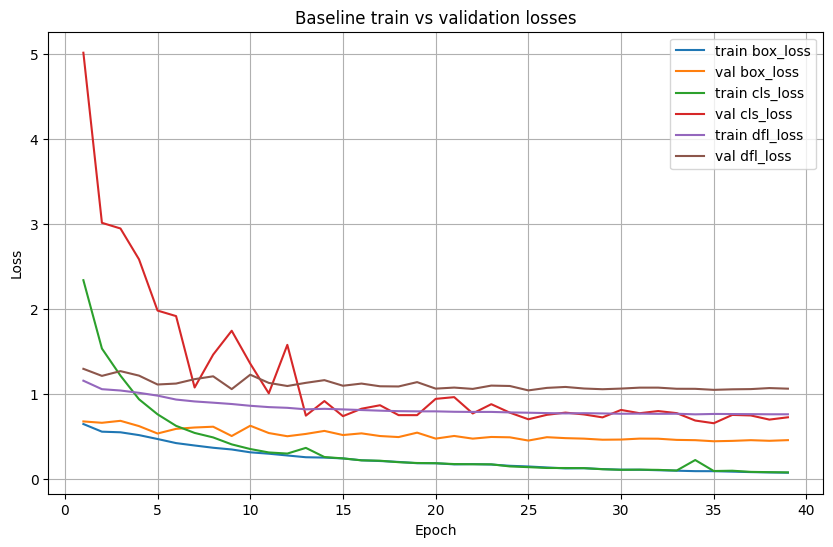

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(baseline_results_df['epoch'], baseline_results_df['train/box_loss'], label='train box_loss')
plt.plot(baseline_results_df['epoch'], baseline_results_df['val/box_loss'], label='val box_loss')
plt.plot(baseline_results_df['epoch'], baseline_results_df['train/cls_loss'], label='train cls_loss')
plt.plot(baseline_results_df['epoch'], baseline_results_df['val/cls_loss'], label='val cls_loss')
plt.plot(baseline_results_df['epoch'], baseline_results_df['train/dfl_loss'], label='train dfl_loss')
plt.plot(baseline_results_df['epoch'], baseline_results_df['val/dfl_loss'], label='val dfl_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline train vs validation losses')
plt.legend()
plt.grid(True)
plt.show()

# Part B — Improved model with data augmentation

Now we train the improved model on the same dataset:

- tomato annotated images;
- negative images with empty labels;
- stronger data augmentation.

This model will be selected as the final best model if it improves robustness and keeps good detection metrics.

## 21. Train improved YOLOv8n model with data augmentation

In [ ]:
AUG_PROJECT = '/content/runs/detect'
AUG_NAME = 'tomato_yolov8n_augmented_with_negatives'

aug_model = YOLO('yolov8n.pt')

aug_results = aug_model.train(
    data=str(DATA_YAML),
    epochs=80,
    imgsz=640,
    batch=16,
    patience=15,
    project=AUG_PROJECT,
    name=AUG_NAME,
    seed=42,
    exist_ok=True,
    lr0=0.001,
    weight_decay=0.0005,
    # data augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.10,
    scale=0.50,
    fliplr=0.50,
    mosaic=1.0,
    mixup=0.10
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tomato_yolov8n_augmented_

## 22. Load improved best model automatically

In [ ]:
aug_best_files = [p for p in Path('/content/runs/detect').rglob('best.pt') if AUG_NAME in str(p)]
if len(aug_best_files) == 0:
    raise FileNotFoundError('Augmented best.pt not found.')

AUG_BEST = max(aug_best_files, key=lambda p: p.stat().st_mtime)
print('Augmented best model:', AUG_BEST)

aug_best_model = YOLO(str(AUG_BEST))

Augmented best model: /content/runs/detect/tomato_yolov8n_augmented_with_negatives/weights/best.pt


## 23. Improved model validation and test metrics

In [ ]:
aug_val_metrics = aug_best_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=640,
    conf=0.50,
    plots=True,
    project='/content/runs/detect',
    name='augmented_validation_conf060'
)

aug_test_metrics = aug_best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    conf=0.50,
    plots=True,
    project='/content/runs/detect',
    name='augmented_test_conf060'
)

aug_metrics_df = pd.DataFrame([
    {
        'model': 'augmented_yolov8n_with_negatives',
        'phase': 'validation',
        'precision': float(aug_val_metrics.box.mp),
        'recall': float(aug_val_metrics.box.mr),
        'mAP50': float(aug_val_metrics.box.map50),
        'mAP50_95': float(aug_val_metrics.box.map),
        'conf_threshold': 0.50,
        'negative_samples': int(n_total)
    },
    {
        'model': 'augmented_yolov8n_with_negatives',
        'phase': 'test',
        'precision': float(aug_test_metrics.box.mp),
        'recall': float(aug_test_metrics.box.mr),
        'mAP50': float(aug_test_metrics.box.map50),
        'mAP50_95': float(aug_test_metrics.box.map),
        'conf_threshold': 0.50,
        'negative_samples': int(n_total)
    }
])

aug_metrics_df

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1359.7±567.9 MB/s, size: 39.0 KB)
val: Scanning /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/labels.cache... 136 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 136/136 51.9Mit/s 0.0s
val: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/images/negative_valid_0008.jpg: corrupt JPEG restored and saved
val: /content/tomato_yolov8_work/tomato_dataset_extracted/Tomato Fruit  Disease Detection.v1i.yolov8/valid/images/negative_valid_0018.jpg: corrupt JPEG restored and saved
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 58, len(boxes) = 172. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
        

,model,phase,precision,recall,mAP50,mAP50_95,conf_threshold,negative_samples
0,augmented_yolov8n_with_negatives,validation,0.965612,0.843281,0.855000,0.747006,0.5,232
1,augmented_yolov8n_with_negatives,test,0.822967,0.811610,0.801157,0.705035,0.5,232


## 24. Compare baseline and improved model

In [ ]:
comparison_df = pd.concat([baseline_metrics_df, aug_metrics_df], ignore_index=True)
comparison_df

,model,phase,precision,recall,mAP50,mAP50_95,conf_threshold,negative_samples
0,baseline_yolov8n_with_negatives,validation,0.945165,0.729752,0.717778,0.659900,0.5,232
1,baseline_yolov8n_with_negatives,test,0.858557,0.706468,0.695483,0.632493,0.5,232
2,augmented_yolov8n_with_negatives,validation,0.965612,0.843281,0.855000,0.747006,0.5,232
3,augmented_yolov8n_with_negatives,test,0.822967,0.811610,0.801157,0.705035,0.5,232


In [ ]:
# Select final model: by default, we select the augmented model with negatives as the final robust model.
# You can change this selection if the metrics are much worse than baseline.
FINAL_MODEL_NAME = 'augmented_yolov8n_with_negatives'
FINAL_MODEL_PATH = AUG_BEST
final_model = aug_best_model

print('Selected final model:', FINAL_MODEL_NAME)
print('Final model path:', FINAL_MODEL_PATH)

Selected final model: augmented_yolov8n_with_negatives
Final model path: /content/runs/detect/tomato_yolov8n_augmented_with_negatives/weights/best.pt


# Part C — Robustness test on negative images

The model should detect tomato-related classes only. It should not detect apples, bananas, peppers, faces, hands, carrots, onions, backgrounds, etc.

Expected result on negative images:

```text
No detections / no bounding boxes
```

## 25. Create a robustness test folder from negative images

In [ ]:
NEG_TEST_DIR = WORK_DIR / 'negative_test_images_for_prediction'
if NEG_TEST_DIR.exists():
    shutil.rmtree(NEG_TEST_DIR)
NEG_TEST_DIR.mkdir(parents=True, exist_ok=True)

# Copy up to 80 negative images for robustness testing
for img_path in negative_images[:80]:
    shutil.copy(img_path, NEG_TEST_DIR / img_path.name)

print('Robustness test images:', len(list(NEG_TEST_DIR.glob('*'))))
print('NEG_TEST_DIR:', NEG_TEST_DIR)

Robustness test images: 80
NEG_TEST_DIR: /content/tomato_yolov8_work/negative_test_images_for_prediction


## 26. Predict on negative images with the final model

There should be no bounding boxes or very few false detections.

In [ ]:
ROBUSTNESS_PRED_NAME = 'final_model_negative_images_conf060'

negative_pred_results = final_model.predict(
    source=str(NEG_TEST_DIR),
    imgsz=640,
    conf=0.50,
    save=True,
    project='/content/runs/detect',
    name=ROBUSTNESS_PRED_NAME,
    verbose=False
)

false_detection_count = 0
images_with_false_detection = 0

for r in negative_pred_results:
    n = len(r.boxes) if r.boxes is not None else 0
    false_detection_count += n
    if n > 0:
        images_with_false_detection += 1

robustness_df = pd.DataFrame([{
    'model': FINAL_MODEL_NAME,
    'phase': 'robustness_test',
    'tested_images': len(negative_pred_results),
    'conf_threshold': 0.50,
    'images_with_false_detection': images_with_false_detection,
    'total_false_detections': false_detection_count
}])

robustness_df

WARNING ⚠️ Image Read Error /content/tomato_yolov8_work/negative_test_images_for_prediction/IMG_3878.JPG
WARNING ⚠️ Image Read Error /content/tomato_yolov8_work/negative_test_images_for_prediction/IMG_3879.JPG
WARNING ⚠️ Image Read Error /content/tomato_yolov8_work/negative_test_images_for_prediction/IMG_3880.JPG
WARNING ⚠️ Image Read Error /content/tomato_yolov8_work/negative_test_images_for_prediction/IMG_3882.JPG
WARNING ⚠️ Image Read Error /content/tomato_yolov8_work/negative_test_images_for_prediction/IMG_3885.JPG
Results saved to /content/runs/detect/final_model_negative_images_conf060-3


,model,phase,tested_images,conf_threshold,images_with_false_detection,total_false_detections
0,augmented_yolov8n_with_negatives,robustness_test,75,0.5,1,1


## 27. Visualize robustness prediction outputs

If you do not see bounding boxes on negative images, that is a good result.

Prediction images found: 75


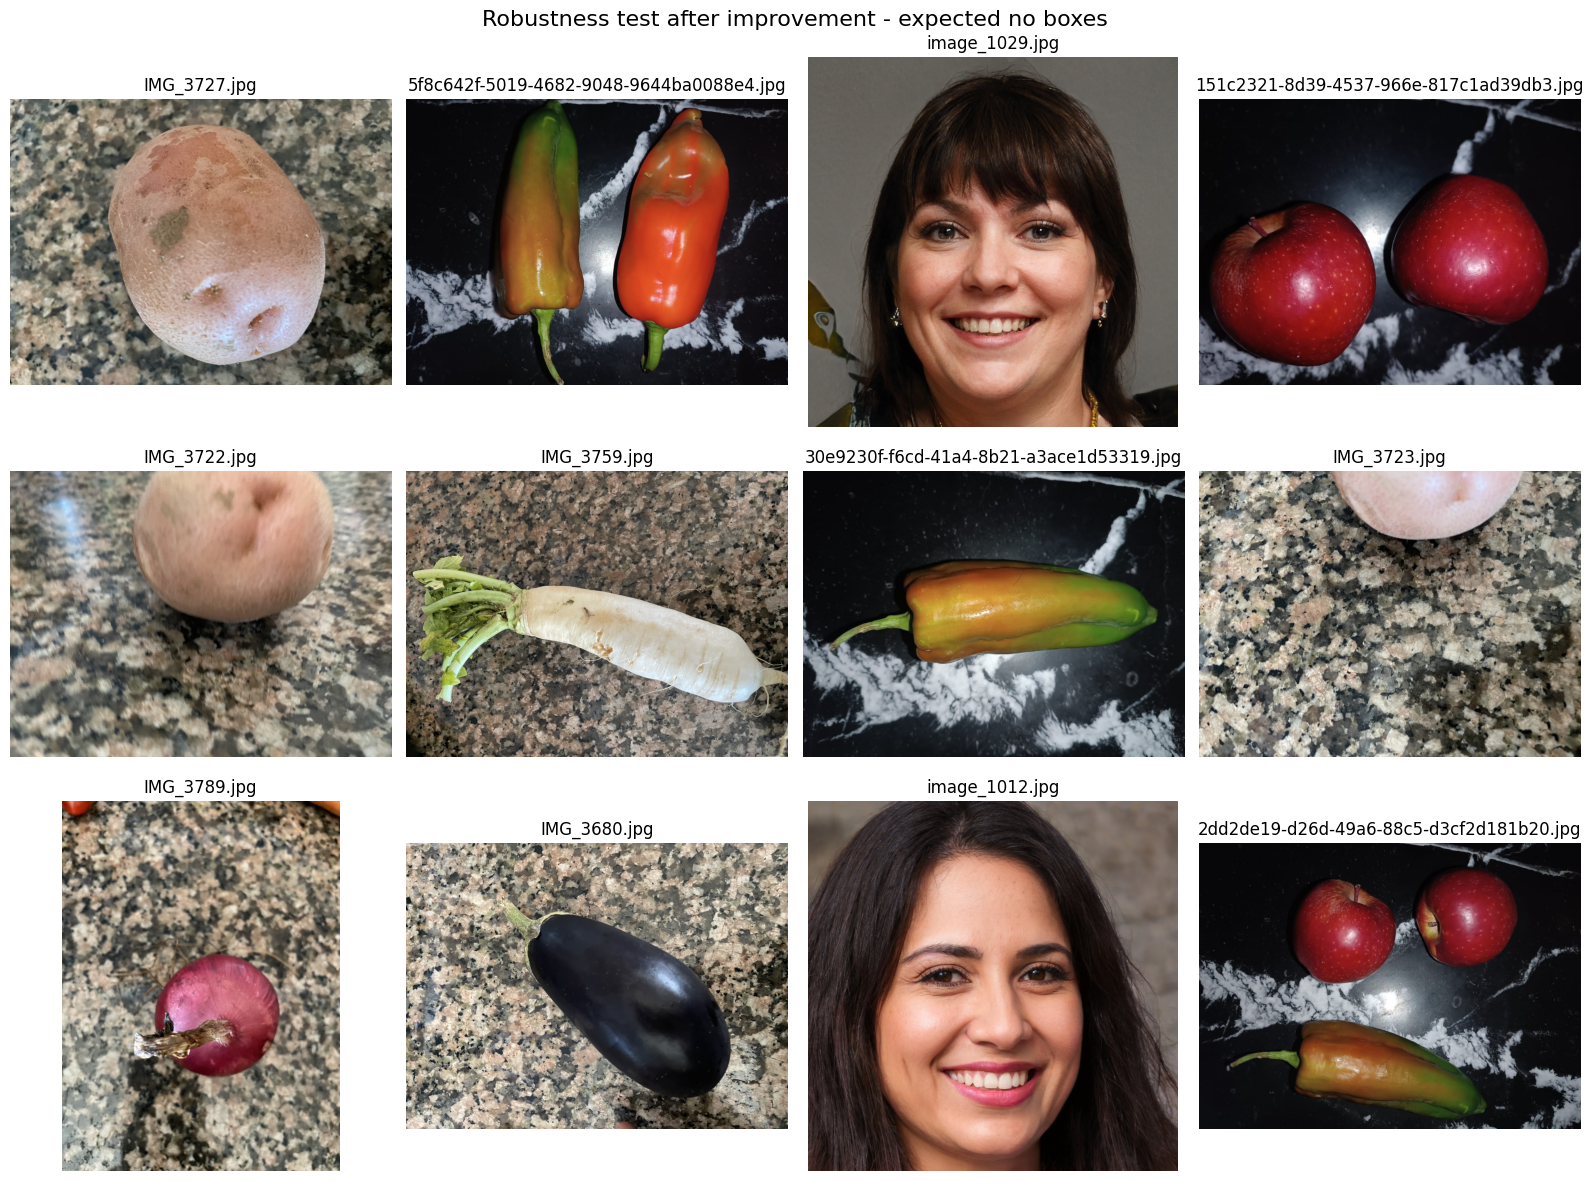

In [ ]:
PRED_DIR = Path('/content/runs/detect') / ROBUSTNESS_PRED_NAME
pred_imgs = [p for p in PRED_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS]
print('Prediction images found:', len(pred_imgs))

show_images_grid(pred_imgs, n=min(12, len(pred_imgs)), title='Robustness test after improvement - expected no boxes')

# Part D — Test with your own new image or camera capture

Upload a new image containing tomato and/or non-tomato objects. The final model should detect tomatoes only and ignore other objects.

In [ ]:
from google.colab import files

uploaded = files.upload()
custom_dir = WORK_DIR / 'custom_test_images'
custom_dir.mkdir(parents=True, exist_ok=True)

for filename in uploaded.keys():
    shutil.move(filename, custom_dir / filename)

print('Uploaded custom images:')
for p in custom_dir.iterdir():
    print('-', p)

Saving spotted_wilt_virus_train-99-_jpg.rf.78418aa231740460934dbbc2981fd62b.jpg to spotted_wilt_virus_train-99-_jpg.rf.78418aa231740460934dbbc2981fd62b.jpg
Uploaded custom images:
- /content/tomato_yolov8_work/custom_test_images/spotted_wilt_virus_train-99-_jpg.rf.78418aa231740460934dbbc2981fd62b.jpg
- /content/tomato_yolov8_work/custom_test_images/3cb9574d-eb7d-49f5-866b-59bfc484b3ba.jpg


Results saved to /content/runs/detect/custom_camera_test_conf060


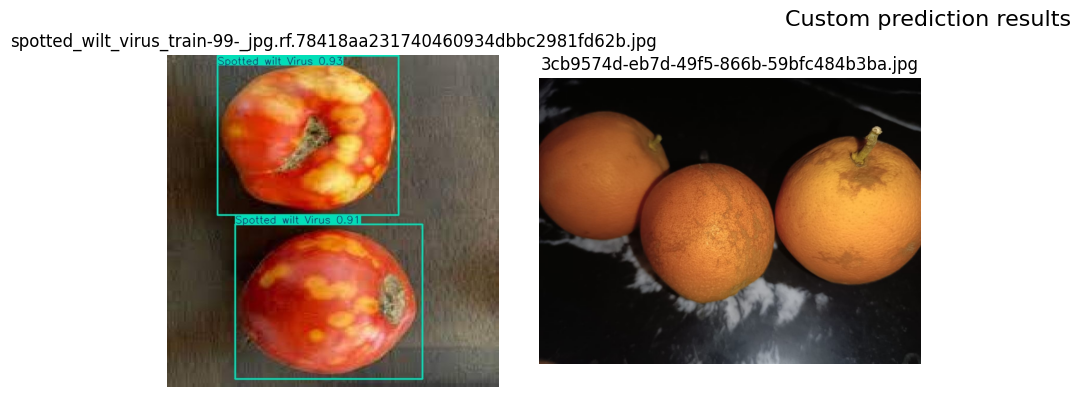

In [ ]:
CUSTOM_PRED_NAME = 'custom_camera_test_conf050'

custom_results = final_model.predict(
    source=str(custom_dir),
    imgsz=640,
    conf=0.60,
    save=True,
    project='/content/runs/detect',
    name=CUSTOM_PRED_NAME
)

CUSTOM_PRED_DIR = Path('/content/runs/detect') / CUSTOM_PRED_NAME
custom_pred_imgs = [p for p in CUSTOM_PRED_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS]
show_images_grid(custom_pred_imgs, n=min(12, len(custom_pred_imgs)), title='Custom prediction results')

# Part E — Save metrics, figures and best model to Google Drive

This cell saves:

- baseline metrics;
- augmented metrics;
- model comparison;
- robustness metrics;
- baseline loss analysis;
- final best model `.pt`;
- important YOLO output figures.

In [ ]:
SAVE_DIR = DRIVE_PROJECT_DIR / 'final_negative_augmented_results'
FIG_DIR = SAVE_DIR / 'figures'
MODEL_DIR = SAVE_DIR / 'models'
METRICS_DIR = SAVE_DIR / 'metrics'

for d in [SAVE_DIR, FIG_DIR, MODEL_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Save metrics
baseline_metrics_df.to_csv(METRICS_DIR / 'baseline_with_negatives_metrics.csv', index=False)
aug_metrics_df.to_csv(METRICS_DIR / 'augmented_with_negatives_metrics.csv', index=False)
comparison_df.to_csv(METRICS_DIR / 'model_comparison_with_negatives.csv', index=False)
robustness_df.to_csv(METRICS_DIR / 'robustness_negative_images_metrics.csv', index=False)
loss_analysis.to_csv(METRICS_DIR / 'baseline_loss_overfitting_analysis.csv', index=False)

# Copy final best model
final_model_drive_path = MODEL_DIR / 'best_yolov8n_augmented_with_negative_samples.pt'
shutil.copy(FINAL_MODEL_PATH, final_model_drive_path)

print('Final model saved to:', final_model_drive_path)
print('Metrics saved to:', METRICS_DIR)

Final model saved to: /content/drive/MyDrive/tomato_yolov8_project/final_negative_augmented_results/models/best_yolov8n_augmented_with_negative_samples.pt
Metrics saved to: /content/drive/MyDrive/tomato_yolov8_project/final_negative_augmented_results/metrics


In [ ]:
# Copy important figures from YOLO runs if they exist
run_dirs_to_copy = [
    BASELINE_RUN_DIR,
    AUG_BEST.parents[1],
    Path('/content/runs/detect') / 'baseline_validation_conf050',
    Path('/content/runs/detect') / 'baseline_test_conf060',
    Path('/content/runs/detect') / 'augmented_validation_conf050',
    Path('/content/runs/detect') / 'augmented_test_conf060',
    Path('/content/runs/detect') / ROBUSTNESS_PRED_NAME,
]

for run_dir in run_dirs_to_copy:
    if run_dir.exists():
        for fig in run_dir.rglob('*'):
            if fig.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
                safe_name = f'{run_dir.name}_{fig.name}'.replace(' ', '_')
                try:
                    shutil.copy(fig, FIG_DIR / safe_name)
                except Exception as e:
                    print('Could not copy:', fig, e)

print('Figures saved to:', FIG_DIR)
print('Number of figures:', len(list(FIG_DIR.glob('*'))))

Figures saved to: /content/drive/MyDrive/tomato_yolov8_project/final_negative_augmented_results/figures
Number of figures: 133


## 28. Create a ZIP file with final results

In [ ]:
FINAL_ZIP = DRIVE_PROJECT_DIR / 'final_negative_augmented_results.zip'

if FINAL_ZIP.exists():
    FINAL_ZIP.unlink()

shutil.make_archive(str(FINAL_ZIP).replace('.zip', ''), 'zip', SAVE_DIR)
print('Final ZIP saved to:', FINAL_ZIP)

Final ZIP saved to: /content/drive/MyDrive/tomato_yolov8_project/final_negative_augmented_results.zip


# Final conclusion

This notebook trains a YOLOv8 model using both annotated tomato images and negative images with empty labels.

The final model is selected from the augmented training with negative samples. It should:

- detect tomatoes and tomato disease classes with bounding boxes;
- ignore non-tomato objects such as apples, bananas, peppers, faces, hands and backgrounds;
- reduce false positive detections using negative samples and `conf=0.50`.

